In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fmnist = tf.keras.datasets.fashion_mnist.load_data()
(X_trainval, y_trainval), (X_test, y_test) = fmnist
X_train, y_train = X_trainval[:-10000], y_trainval[:-10000]
X_valid, y_valid = X_trainval[-10000:], y_trainval[-10000:]
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.
X_train = X_train.reshape([-1, 28, 28, 1])
X_valid = X_valid.reshape([-1, 28, 28, 1])
X_test = X_test.reshape([-1, 28, 28, 1])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
def plot_reconstructions(model, images, original_images, n_images=10):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1) #restrict predicted pixel values to lie between 0 and 1
    fig = plt.figure(figsize=(n_images * 1.5, 4.5))
    for image_index in range(n_images):
        plt.subplot(3, n_images, 1 + image_index)
        plt.imshow(original_images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(3, n_images, 1 + n_images + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(3, n_images, 1 + 2*n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")
    plt.show()

In [4]:
def create_masked_images(images, mask_type = 'tophalf'):
    masked_images = images.copy()
    if mask_type == 'random':
        mask = np.random.rand(*masked_images.shape) > 0.5
        masked_images = masked_images * mask
    elif mask_type == 'tophalf':
        masked_images[:, 14:, :, :] = 0
    elif mask_type == 'white':
        masked_images[:, :, :, :] = 0
    else:
        raise ValueError("Invalid mask type.")
    return masked_images

In [9]:
masked_X_train = create_masked_images(X_train, mask_type = "random")
masked_X_valid = create_masked_images(X_valid, mask_type = "random")
masked_X_test = create_masked_images(X_test, mask_type = "random")

In [10]:
encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu', kernel_initializer = 'he_normal'),
    tf.keras.layers.Dense(32, activation = 'relu', kernel_initializer = 'he_normal')
])

decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation = 'relu', kernel_initializer = 'he_normal'),
    tf.keras.layers.Dense(28*28),
    tf.keras.layers.Reshape([28, 28])
])

ae = tf.keras.Sequential([encoder, decoder])

ae.compile(loss = "mse", optimizer = "nadam")
history = ae.fit(masked_X_train, X_train, epochs = 20, validation_data = (masked_X_valid, X_valid))

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0419 - val_loss: 0.0234
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0225 - val_loss: 0.0216
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0209 - val_loss: 0.0208
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0201 - val_loss: 0.0201
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0197 - val_loss: 0.0199
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0193 - val_loss: 0.0196
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0190 - val_loss: 0.0193
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0188 - val_loss: 0.0192
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0186 - val_loss: 0.0191
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0184 - val_loss: 0.0190
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0182 - val_loss: 0.0189
Epoch 12/20
1563/1563 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


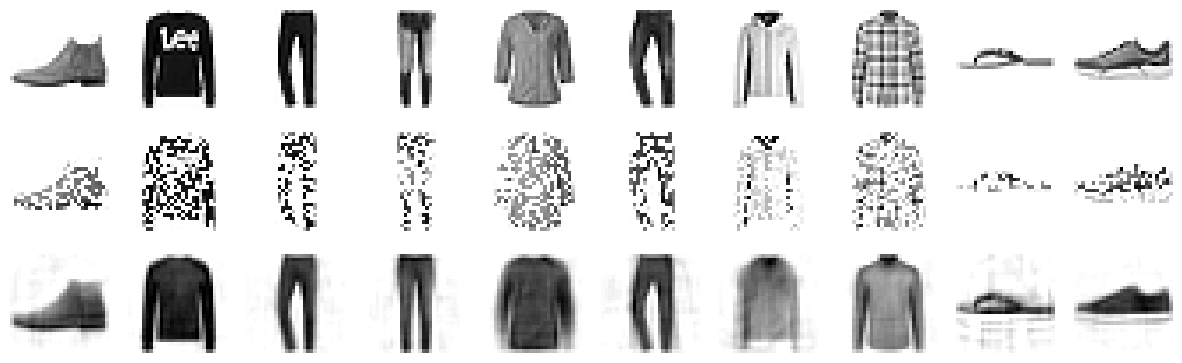

In [11]:
plot_reconstructions(ae, masked_X_test, X_test)